<a href="https://colab.research.google.com/github/Noory6m/lab-11/blob/main/02_Credit_Card_Customer_Segmentation_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ARTI308 - Machine Learning

# Credit Card Customer Segmentation Project

In this project, you will use K-Means clustering to segment [credit card customers](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata/data) based on their usage behavior. This is an unsupervised learning problem because the dataset does not contain a target label for customer groups.

You will use the `CC_GENERAL.csv` dataset.

## About the Dataset

The dataset contains customer-level credit card usage behavior. Each row represents one credit card holder, and the columns describe different behavioral variables such as balance, purchases, cash advance, payments, and tenure. The goal is to group similar customers together so that the company can understand different customer segments and design better marketing strategies.

## Import Libraries

**Import the libraries you need for data analysis, visualization, preprocessing, clustering, and evaluation.**

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## Get the Data

**Read the `CC_GENERAL.csv` file and save it in a dataframe called `df`.**

In [32]:
 df = pd.read_csv('CC_GENERAL.csv')

**Check the first five rows of the dataset.**

In [33]:
 df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


**Check the shape of the dataset.**

In [4]:
 df.shape

(8950, 18)

**Check basic information about the dataset using `info()`.**

In [5]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

**Check summary statistics using `describe()`.**

In [6]:
 df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Data Cleaning

The column `CUST_ID` is an identification column. It is not useful for clustering because it does not describe customer behavior.

**Drop the `CUST_ID` column from the dataframe.**

In [7]:
 df = df.drop('CUST_ID', axis=1)

**Check the missing values in each column.**

In [8]:
 df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


Some columns may contain missing values.

Hint: You can handle missing values by either:
- filling them with the mean value
- or dropping the rows that contain missing values

For this project, use mean imputation.

**Fill the missing values with the mean of each column.**

In [9]:
 df = df.fillna(df.mean())

**Check the missing values again to make sure they were handled.**

In [10]:
 df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


## Exploratory Data Analysis

Before applying clustering, it is important to understand the data.

**Create histograms for the numerical columns.**

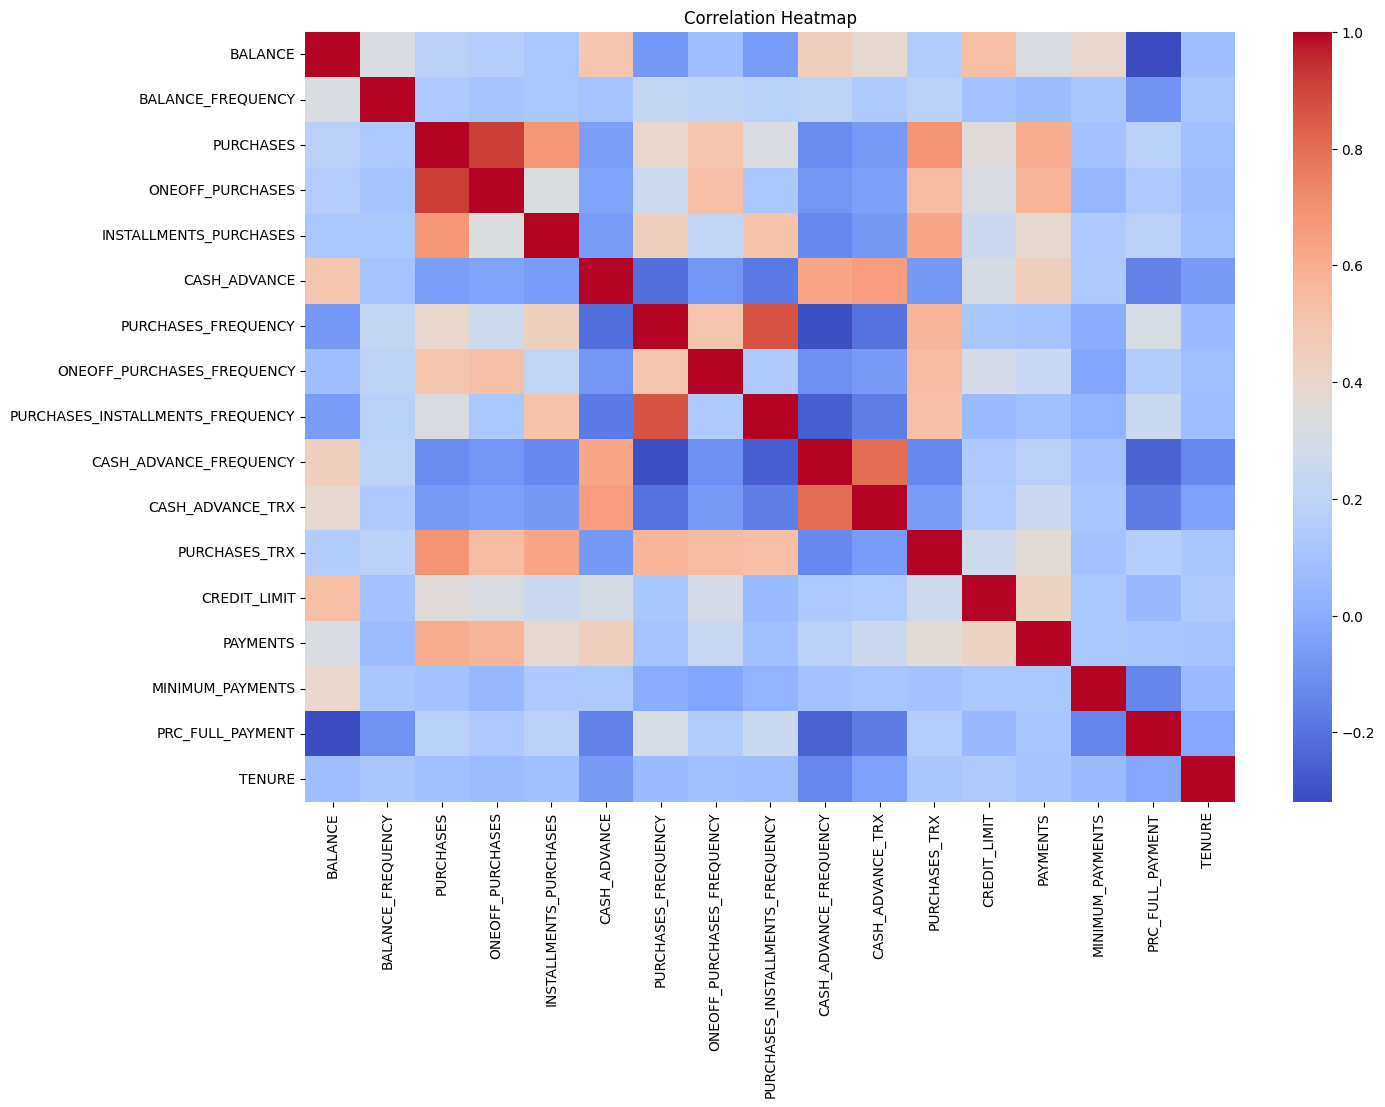

In [11]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Create a correlation heatmap to understand relationships between the features.**

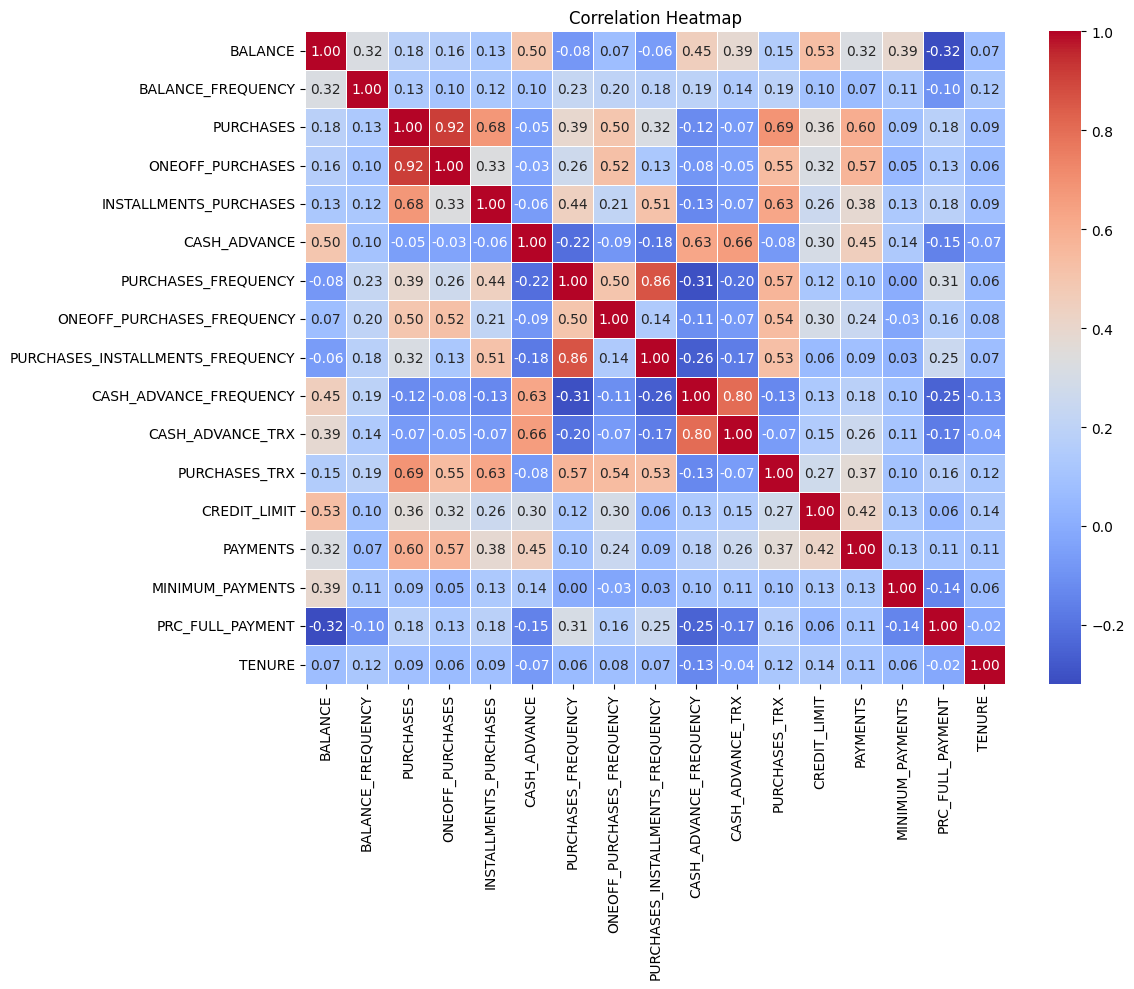

In [22]:
 plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Create a scatter plot between `BALANCE` and `PURCHASES`.**

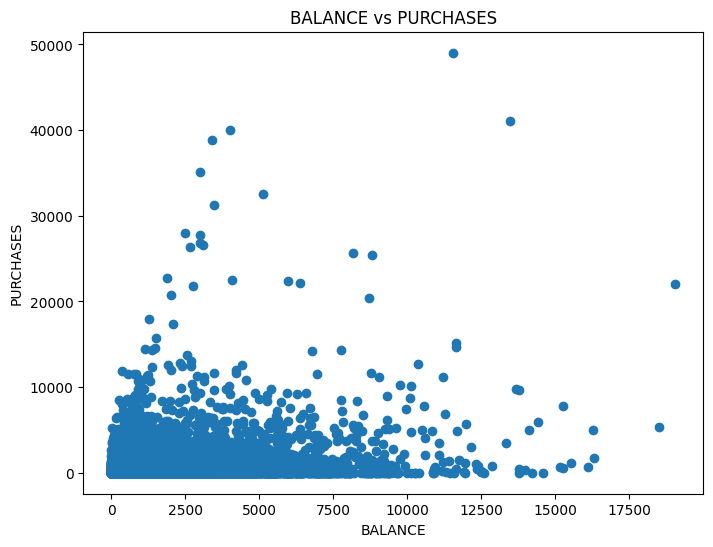

In [12]:
 plt.figure(figsize=(8,6))
plt.scatter(df['BALANCE'], df['PURCHASES'])
plt.xlabel('BALANCE')
plt.ylabel('PURCHASES')
plt.title('BALANCE vs PURCHASES')
plt.show()

**Create a scatter plot between `BALANCE` and `CASH_ADVANCE`.**

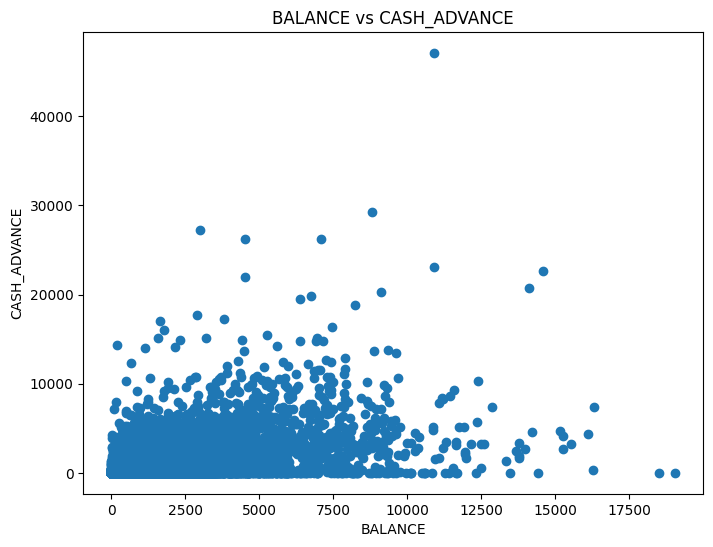

In [13]:
 plt.figure(figsize=(8,6))
plt.scatter(df['BALANCE'], df['CASH_ADVANCE'])
plt.xlabel('BALANCE')
plt.ylabel('CASH_ADVANCE')
plt.title('BALANCE vs CASH_ADVANCE')
plt.show()

## Feature Scaling

K-Means is a distance-based algorithm. Therefore, feature scaling is very important.

The features in this dataset have very different ranges. For example, `BALANCE`, `PURCHASES`, and `CREDIT_LIMIT` may have large values, while frequency columns are between 0 and 1.

**Use StandardScaler to scale the data. Save the scaled data in a variable called `X_scaled`.**

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## Choosing K Intuitively

Choosing K is one of the most difficult parts of K-Means.

Since this dataset has many features, it is not easy to visually see the clusters directly.

However, we can still compare different K values using the elbow method and silhouette score.

## Elbow Method

**Create a loop that fits K-Means models for K values from 1 to 10. Save the inertia values in a list called `inertia_values`.**

In [19]:
inertia_values = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

**Plot the elbow curve.**

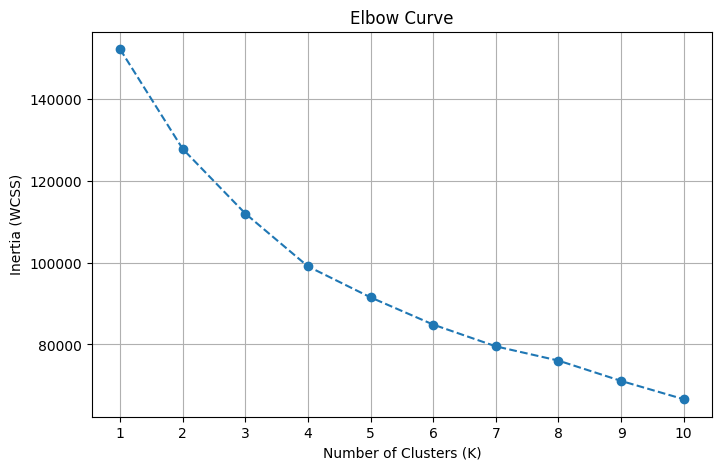

In [20]:
 plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia_values, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Curve')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

**Output Interpretation**

Look at the elbow curve and try to identify where the decrease in inertia starts to slow down.

That point can suggest a reasonable value for K.

## Silhouette Score

The silhouette score helps evaluate how well-separated the clusters are.

**Create a loop that calculates the silhouette score for K values from 2 to 10. Save the scores in a list called `silhouette_scores`.**

In [21]:
 silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

**Plot the silhouette scores.**

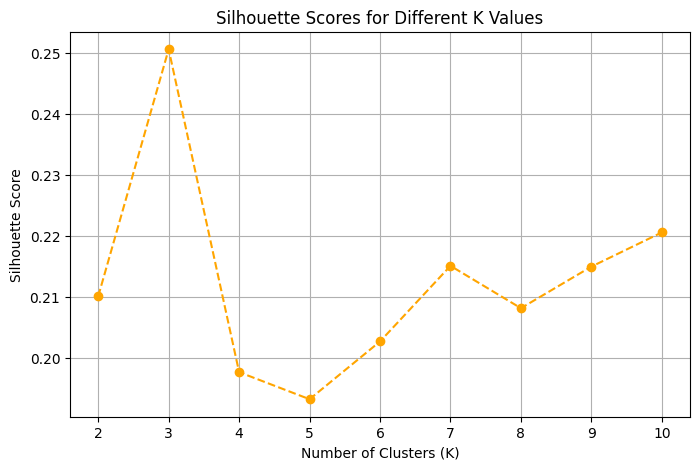

In [23]:
 plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='orange', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different K Values')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

**Create a table showing each K value and its silhouette score.**

In [24]:
 silhouette_df = pd.DataFrame({
    'K': range(2, 11),
    'Silhouette Score': silhouette_scores
})
silhouette_df

,K,Silhouette Score
0,2,0.210033
1,3,0.250556
2,4,0.197607
3,5,0.193169
4,6,0.202639
5,7,0.215038
6,8,0.208092
7,9,0.214912
8,10,0.220518


**Output Interpretation**

A higher silhouette score usually means better clustering.

However, do not rely only on the highest value. Also consider whether the chosen K makes sense for customer segmentation.

## Create the Final K-Means Model

**Based on the elbow curve and silhouette scores, choose a final K value. Then train a final K-Means model.**

Use `random_state=42` and `n_init=10`.

In [25]:
 # K=3 yields the highest overall silhouette score (~0.251)
best_k = 3
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
final_kmeans.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

**Add the final cluster labels to the original dataframe in a new column called `Cluster`.**

In [26]:
 df['Cluster'] = final_kmeans.labels_

**Check the first five rows after adding the cluster labels.**

In [27]:
 df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,2
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,2
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,2
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,2


## Cluster Analysis

Now we need to understand what each cluster means.

**Create a summary table using `groupby()` to show the mean values of each feature for each cluster.**

In [28]:
 cluster_summary = df.groupby('Cluster').mean()
cluster_summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,3989.326804,0.957980,384.528277,248.718133,135.887632,3869.856855,0.232290,0.110942,0.144242,0.447176,12.390351,5.612155,6682.960242,3018.907202,1795.687341,0.033774,11.350877
1,2220.003291,0.981477,4268.520980,2717.828543,1551.178267,458.421147,0.949093,0.668166,0.744584,0.063014,1.528745,56.472065,7733.967611,4151.276172,1224.538588,0.298632,11.923077
2,799.702576,0.835188,505.532394,253.120131,252.733061,329.866776,0.465072,0.132333,0.345145,0.068316,1.211636,8.653865,3269.793763,909.729614,548.525315,0.155750,11.478836


**Check how many customers are in each cluster.**

In [29]:
 df['Cluster'].value_counts()

,count
Cluster,
2,6119
0,1596
1,1235


## Visualizing the Final Clusters

Since the dataset has many features, we will use PCA to reduce the data into two components only for visualization.

This visualization does not replace the original clustering. It only helps us see the clusters in a 2D plot.

**Use PCA with 2 components and plot the clusters.**

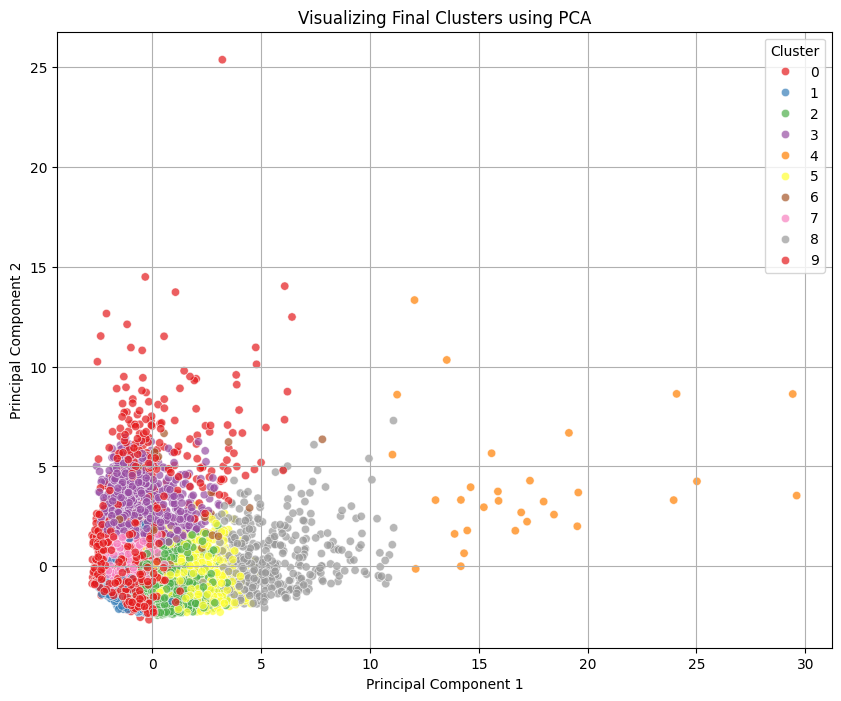

In [37]:
# Create the column first
df['Cluster'] = kmeans.labels_

# Now your PCA code will work perfectly
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='Set1', alpha=0.7)
plt.title('Visualizing Final Clusters using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

**Output Interpretation**

The PCA plot gives a simplified 2D view of the clusters.

If the clusters are not perfectly separated, that is normal because the original dataset has many features and the plot only shows two compressed dimensions.

## Final Questions

Answer the following questions:

1. Why is this an unsupervised learning problem?

2. Why did we remove the `CUST_ID` column?

3. Which columns had missing values?

4. How did you handle the missing values?

5. Why is scaling important before applying K-Means?

6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.

7. Based on the cluster summary table, describe each customer segment in your own words.

8. Which cluster may represent high-value customers?

9. Which cluster may represent customers who rely more on cash advance?

10. How can a company use these clusters for marketing strategy?

In [ ]:
#1. Why is this an unsupervised learning problem?Answer: This is an unsupervised learning problem because the dataset does not contain predefined target labels or correct responses (e.g., historical user groupings). The algorithm must independently discover intrinsic patterns, similarities, and structures to group the customers based on their behavioral features alone.2. Why did we remove the CUST_ID column?Answer: CUST_ID is a unique database identifier string assigned to each customer record. It has no behavioral meaning or statistical value. Keeping it would skew distance metric computations (like Euclidean distance) because every single record would appear distant and unique due to its identifier rather than its actual credit card usage behavior.3. Which columns had missing values?Answer: Two columns had missing values:CREDIT_LIMIT (1 missing value)MINIMUM_PAYMENTS (313 missing values)4. How did you handle the missing values?Answer: We handled missing values via mean imputation, replacing the blank data entries with the mathematical average value calculated from the rest of the available non-missing entries within those respective columns.5. Why is scaling important before applying K-Means?Answer: K-Means calculates distance metrics to group objects. Features with large numerical spans (such as CREDIT_LIMIT or BALANCE, which can be thousands of dollars) naturally produce massive distance deviations compared to small-scale metrics like transaction frequencies (which range strictly from 0 to 1). Feature scaling standardizes features onto an identical variance scale so that every column shares an equal weighting in defining the cluster assignments.6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.Answer: We chose $K = 3$. The Elbow Method indicates a noticeable reduction in the rate of inertia drop (forming the elbow) around $K = 3$. Furthermore, the Silhouette Score reaches its maximum peak value of roughly $0.251$ at exactly $K = 3$, mathematically confirming that three clusters provide the most cohesive and well-separated grouping boundaries.7. Based on the cluster summary table, describe each customer segment in your own words.Answer: * Cluster 0 (Cash Borrowers): Customers carrying high account balances with low purchase activity, but very heavy reliance on cash advances. They exhibit high cash advance frequencies and transactions, while making minimal full balance statements pay-offs.Cluster 1 (High-Value VIP Spenders): Highly active customers who spend extensively across both one-off items and installment options. They possess high credit limits, do a massive number of purchase transactions, and frequently settle large payment amounts.Cluster 2 (Frugal/Budget Users): The largest segment. These users maintain lower balances, do minimal purchasing, rarely take cash advances, and operate on modest credit limits. They use credit cards strictly when necessary.8. Which cluster may represent high-value customers?Answer: Cluster 1 represents high-value customers because they have the largest total purchasing footprint ($\approx \$4,268.52$ average purchases), utilize a high credit ceiling, interact heavily with card operations, and maintain excellent repayment rates.9. Which cluster may represent customers who rely more on cash advance?Answer: Cluster 0 represents cash-advance reliant users, displaying a high cash advance value profile ($\approx \$3,869.86$ average cash advance) and a vastly greater cash advance frequency rate ($0.45$) than any other segment.10. How can a company use these clusters for marketing strategy?Answer: * For Cluster 0 (Cash Borrowers): Market balance transfer features, low-fee cash advance windows, or introduce purchase incentive structures (like cashback points) to convert cash withdrawals into store transaction operations.For Cluster 1 (High-Value VIP Spenders): Retain them through premium-tier credit upgrades, point-heavy reward programs, flight/travel lounge benefits, and high-end lifestyle promotional partnerships.For Cluster 2 (Frugal/Budget Users): Boost activity using targeted partner coupons, introductory low-interest installment fee structures, or zero-annual-fee compliance rewards to prompt more consistent monthly transactions.